In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.2 MB/s eta 0:00:00


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
!pip install kagglehub -q

import kagglehub
ajifoster3_yolo_annotated_wind_turbines_586x371_path = kagglehub.dataset_download('ajifoster3/yolo-annotated-wind-turbines-586x371')
print('Data source import complete.')


100%|██████████| 2.57G/2.57G [02:26<00:00, 18.9MB/s]

Extracting files...


Data source import complete.


In [ ]:
"""
================================================================
 MQ02 풍력터빈 손상탐지 — 팀 공통 베이스 코드 (이 파일 하나면 됩니다)
================================================================
 하는 일:  데이터 split(자동)  →  내 모델 학습  →  결과 출력
 사용법 :  맨 위 [설정]에서 "MODEL"과 "SRC 경로"만 내 환경에 맞게 바꾸고 실행!
           (캐글/코랩/로컬 경로 예시는 SRC 주석 참고)
 ★ 학습 설정(epochs/imgsz/batch/seed)은 팀 전원 동일해야 비교가 공정합니다 — 건드리지 마세요.
"""
import os, glob, random, shutil

# ══════════════════ [설정] 여기 두 개만 바꾸세요 ══════════════════
MODEL = "yolo12s.pt"   # ★ 내가 배정받은 모델. 예: yolo11s.pt / yolov10s.pt / yolo12s.pt / rtdetr-l.pt

SRC = os.path.join(ajifoster3_yolo_annotated_wind_turbines_586x371_path, "NordTank586x371")  # ★ 데이터 위치
#  ▶ 캐글:  SRC = "/kaggle/input/yolo-annotated-wind-turbines-586x371/NordTank586x371"
#  ▶ 코랩:  SRC = "/content/NordTank586x371"

OUT = "./split"        # split 결과가 저장될 곳 (보통 안 바꿔도 됨)
# ─────────────────── 아래 설정은 전원 동일, 건드리지 마세요 ───────────────────
EPOCHS, IMGSZ, BATCH, SEED = 50, 640, 16, 42
RATIO = (0.8, 0.1, 0.1)   # train / val / test
# ════════════════════════════════════════════════════════════════


def prepare_split():
    """데이터를 train/val/test로 나눠 split 폴더 + data.yaml 생성.
       Dirt가 희귀(1:15)해서 'Dirt 포함 여부'로 층화 분할한다. seed 고정 → 모두 동일."""
    img_dir, lbl_dir = os.path.join(SRC, "images"), os.path.join(SRC, "labels")
    # labels.txt 는 클래스이름 파일이라 제외
    label_files = sorted(f for f in glob.glob(os.path.join(lbl_dir, "*.txt"))
                         if os.path.basename(f) != "labels.txt")
    items = []  # (base, img, lbl, has_dirt)
    for lf in label_files:
        base = os.path.splitext(os.path.basename(lf))[0]
        img = os.path.join(img_dir, base + ".png")
        if not os.path.exists(img):
            continue
        has_dirt = any(line.strip().startswith("0 ") for line in open(lf))
        items.append((base, img, lf, has_dirt))

    def split_group(group):
        g = sorted(group, key=lambda x: x[0]); random.Random(SEED).shuffle(g)
        n = len(g); a = int(n*RATIO[0]); b = int(n*RATIO[1])
        return g[:a], g[a:a+b], g[a+b:]

    dirt   = [it for it in items if it[3]]
    nodirt = [it for it in items if not it[3]]
    d = split_group(dirt); nd = split_group(nodirt)
    splits = {"train": d[0]+nd[0], "val": d[1]+nd[1], "test": d[2]+nd[2]}

    if os.path.exists(OUT): shutil.rmtree(OUT)
    for sp, rows in splits.items():
        os.makedirs(os.path.join(OUT, sp, "images"), exist_ok=True)
        os.makedirs(os.path.join(OUT, sp, "labels"), exist_ok=True)
        for base, img, lbl, _ in rows:
            shutil.copy2(img, os.path.join(OUT, sp, "images", base+".png"))
            shutil.copy2(lbl, os.path.join(OUT, sp, "labels", base+".txt"))

    yaml_path = os.path.abspath(os.path.join(OUT, "data.yaml"))
    with open(yaml_path, "w") as f:
        f.write(f"path: {os.path.abspath(OUT)}\n")
        f.write("train: train/images\nval: val/images\ntest: test/images\n")
        f.write("nc: 2\nnames:\n  0: dirt\n  1: damage\n")
    for sp in ("train","val","test"):
        rows = splits[sp]; di = sum(1 for r in rows if r[3])
        print(f"  {sp:5} {len(rows):4}장 (Dirt포함 {di})")
    return yaml_path


def main():
    print("[1/2] 데이터 split 생성...")
    data_yaml = prepare_split()
    print("      data.yaml:", data_yaml)

    print(f"[2/2] 학습 시작 — 모델: {MODEL}")
    # rtdetr 만 클래스가 다름, 나머지(yolo계열)는 전부 YOLO
    if MODEL.lower().startswith("rtdetr"):
        from ultralytics import RTDETR as Net
    else:
        from ultralytics import YOLO as Net
    model = Net(MODEL)
    model.train(data=data_yaml, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
                device=0, seed=SEED, project="runs", name=MODEL.split(".")[0],
                exist_ok=True, workers=0)

    # 최종: 한 번도 안 본 test 셋으로 정직하게 평가 (클래스별 AP 포함)
    print("[+] test 셋 최종 평가...")
    metrics = model.val(data=data_yaml, split="test")
    print("    test mAP50   :", round(float(metrics.box.map50), 4))
    print("    test mAP50-95:", round(float(metrics.box.map), 4))


if __name__ == "__main__":
    main()


[1/2] 데이터 split 생성...
  train 2395장 (Dirt포함 450)
  val    299장 (Dirt포함 56)
  test   301장 (Dirt포함 57)
      data.yaml: /content/split/data.yaml
[2/2] 학습 시작 — 모델: yolo12s.pt
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic

[백업] results.csv 없음 → 로그 하드코딩 값 사용
[저장] training_metrics.png


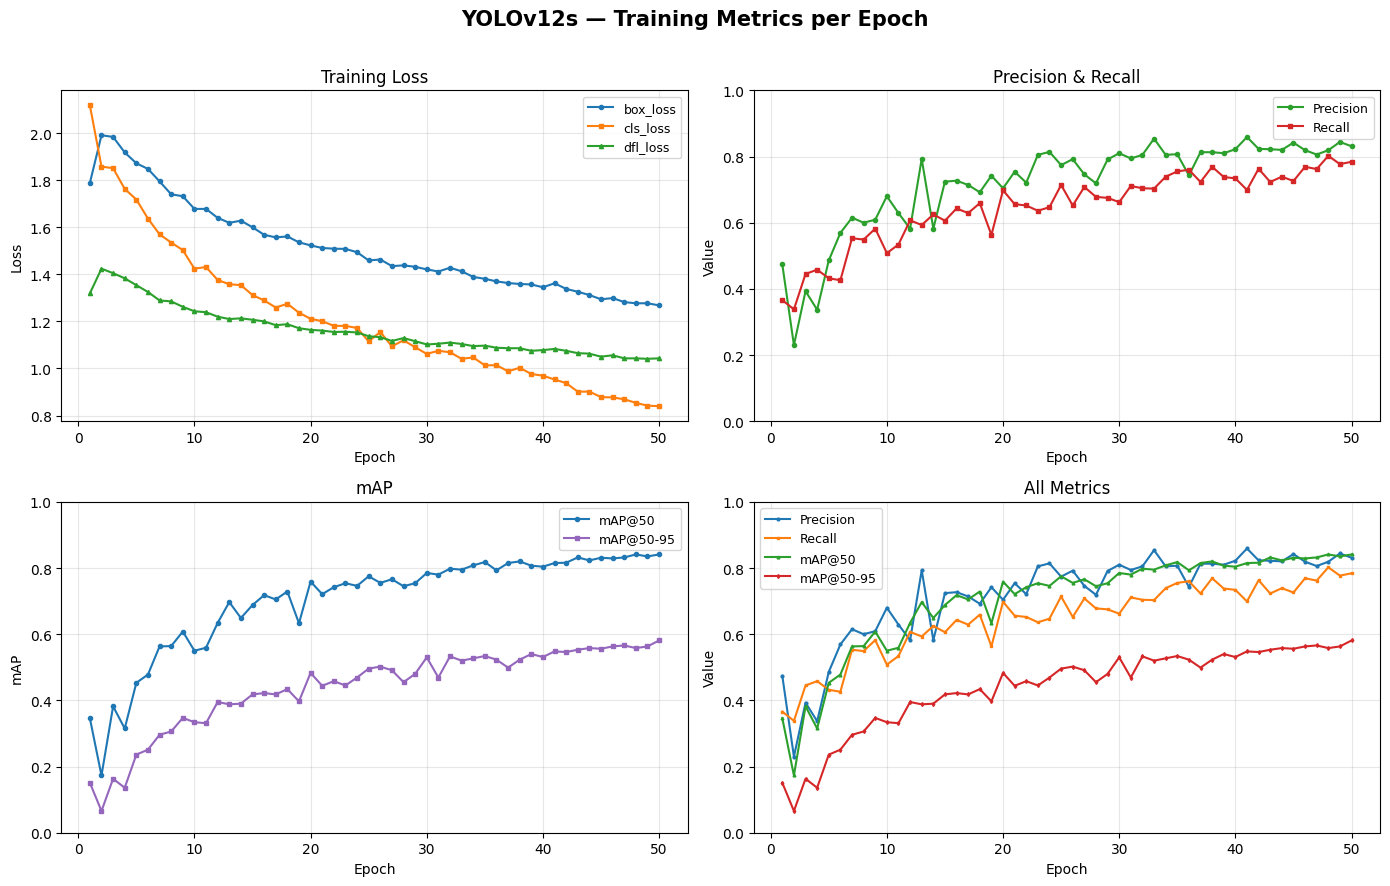

In [ ]:
"""
================================================================
 YOLO 학습 결과 → 에폭별 주요 지표 꺾은선 그래프
================================================================
 그리는 지표:
   · 손실(Loss)   : box_loss / cls_loss / dfl_loss
   · 성능(Metric) : Precision / Recall / mAP50 / mAP50-95

 데이터 소스 (자동 선택):
   1) runs/.../results.csv 가 있으면 그걸 읽음  (제일 정확, 권장)
   2) 없으면 아래에 하드코딩된 로그 값(50 에폭)을 사용
================================================================
"""
import os
import matplotlib.pyplot as plt

# ── (선택) Ultralytics가 저장하는 results.csv 경로. 있으면 자동 사용 ──
RESULTS_CSV = "runs/detect/runs/yolo12s/results.csv"   # ★ 본인 run 폴더에 맞게

# ── 로그에서 뽑아둔 에폭별 값 (results.csv 못 찾을 때의 백업) ──────────
EPOCH = list(range(1, 51))
BOX = [1.788,1.991,1.984,1.918,1.872,1.848,1.795,1.740,1.732,1.678,
       1.678,1.640,1.619,1.628,1.600,1.568,1.557,1.561,1.536,1.523,
       1.512,1.509,1.508,1.494,1.459,1.463,1.435,1.438,1.432,1.421,
       1.412,1.428,1.413,1.389,1.381,1.370,1.363,1.359,1.357,1.345,
       1.362,1.338,1.326,1.312,1.294,1.299,1.282,1.277,1.277,1.268]
CLS = [2.118,1.858,1.851,1.763,1.718,1.637,1.570,1.535,1.503,1.424,
       1.431,1.376,1.358,1.354,1.312,1.289,1.259,1.275,1.237,1.211,
       1.201,1.181,1.181,1.172,1.115,1.155,1.094,1.120,1.090,1.062,
       1.075,1.069,1.041,1.047,1.013,1.014,0.9878,1.003,0.9763,0.9695,
       0.9531,0.9376,0.9015,0.9016,0.8783,0.8769,0.8691,0.8537,0.8419,0.8397]
DFL = [1.319,1.424,1.405,1.383,1.354,1.325,1.289,1.285,1.262,1.243,
       1.239,1.220,1.210,1.213,1.207,1.200,1.184,1.188,1.171,1.164,
       1.161,1.155,1.156,1.153,1.137,1.133,1.117,1.129,1.116,1.102,
       1.105,1.110,1.104,1.095,1.097,1.088,1.086,1.086,1.075,1.078,
       1.083,1.075,1.065,1.063,1.050,1.056,1.043,1.043,1.041,1.043]
P  = [0.474,0.230,0.393,0.337,0.486,0.569,0.615,0.600,0.609,0.680,
      0.629,0.582,0.793,0.582,0.724,0.727,0.714,0.692,0.742,0.704,
      0.754,0.721,0.805,0.814,0.774,0.792,0.746,0.719,0.791,0.810,
      0.794,0.805,0.854,0.805,0.807,0.743,0.813,0.813,0.810,0.822,
      0.859,0.823,0.822,0.820,0.842,0.819,0.806,0.819,0.844,0.831]
R  = [0.366,0.338,0.445,0.458,0.432,0.426,0.553,0.549,0.582,0.508,
      0.534,0.607,0.593,0.625,0.606,0.643,0.629,0.659,0.563,0.698,
      0.656,0.652,0.636,0.647,0.714,0.652,0.708,0.678,0.675,0.662,
      0.711,0.704,0.703,0.739,0.755,0.760,0.723,0.769,0.738,0.734,
      0.699,0.763,0.723,0.739,0.726,0.769,0.762,0.802,0.777,0.784]
MAP50 = [0.346,0.173,0.382,0.315,0.453,0.478,0.563,0.564,0.608,0.550,
         0.559,0.634,0.697,0.649,0.688,0.718,0.705,0.729,0.633,0.759,
         0.721,0.742,0.754,0.746,0.775,0.755,0.766,0.745,0.754,0.785,
         0.780,0.798,0.795,0.808,0.818,0.793,0.815,0.820,0.807,0.804,
         0.815,0.816,0.832,0.823,0.831,0.829,0.832,0.841,0.835,0.841]
MAP = [0.151,0.0657,0.163,0.136,0.236,0.251,0.296,0.306,0.347,0.334,
       0.331,0.395,0.388,0.390,0.418,0.422,0.418,0.434,0.397,0.483,
       0.444,0.458,0.445,0.469,0.496,0.502,0.491,0.455,0.480,0.530,
       0.469,0.533,0.520,0.527,0.534,0.523,0.499,0.523,0.540,0.531,
       0.548,0.546,0.553,0.558,0.556,0.563,0.566,0.558,0.563,0.581]


def load_data():
    """results.csv 가 있으면 거기서, 없으면 위 하드코딩 값에서 지표를 읽어온다."""
    if os.path.exists(RESULTS_CSV):
        import pandas as pd
        df = pd.read_csv(RESULTS_CSV)
        df.columns = [c.strip() for c in df.columns]
        print(f"[읽음] {RESULTS_CSV} ({len(df)} 에폭)")
        return dict(
            epoch=df["epoch"].tolist(),
            box=df["train/box_loss"].tolist(),
            cls=df["train/cls_loss"].tolist(),
            dfl=df["train/dfl_loss"].tolist(),
            p=df["metrics/precision(B)"].tolist(),
            r=df["metrics/recall(B)"].tolist(),
            map50=df["metrics/mAP50(B)"].tolist(),
            map=df["metrics/mAP50-95(B)"].tolist(),
        )
    print("[백업] results.csv 없음 → 로그 하드코딩 값 사용")
    return dict(epoch=EPOCH, box=BOX, cls=CLS, dfl=DFL,
                p=P, r=R, map50=MAP50, map=MAP)


def main():
    d = load_data()
    e = d["epoch"]

    fig, ax = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("YOLOv12s — Training Metrics per Epoch", fontsize=15, fontweight="bold")

    # (0,0) 손실 3종
    ax[0, 0].plot(e, d["box"], marker="o", ms=3, label="box_loss")
    ax[0, 0].plot(e, d["cls"], marker="s", ms=3, label="cls_loss")
    ax[0, 0].plot(e, d["dfl"], marker="^", ms=3, label="dfl_loss")
    ax[0, 0].set_title("Training Loss")
    ax[0, 0].set_xlabel("Epoch"); ax[0, 0].set_ylabel("Loss")

    # (0,1) Precision & Recall
    ax[0, 1].plot(e, d["p"], marker="o", ms=3, color="tab:green", label="Precision")
    ax[0, 1].plot(e, d["r"], marker="s", ms=3, color="tab:red", label="Recall")
    ax[0, 1].set_title("Precision & Recall")
    ax[0, 1].set_xlabel("Epoch"); ax[0, 1].set_ylabel("Value"); ax[0, 1].set_ylim(0, 1)

    # (1,0) mAP
    ax[1, 0].plot(e, d["map50"], marker="o", ms=3, color="tab:blue", label="mAP@50")
    ax[1, 0].plot(e, d["map"], marker="s", ms=3, color="tab:purple", label="mAP@50-95")
    ax[1, 0].set_title("mAP")
    ax[1, 0].set_xlabel("Epoch"); ax[1, 0].set_ylabel("mAP"); ax[1, 0].set_ylim(0, 1)

    # (1,1) 성능 지표 4종 한 판에
    ax[1, 1].plot(e, d["p"], marker="o", ms=2, label="Precision")
    ax[1, 1].plot(e, d["r"], marker="s", ms=2, label="Recall")
    ax[1, 1].plot(e, d["map50"], marker="^", ms=2, label="mAP@50")
    ax[1, 1].plot(e, d["map"], marker="d", ms=2, label="mAP@50-95")
    ax[1, 1].set_title("All Metrics")
    ax[1, 1].set_xlabel("Epoch"); ax[1, 1].set_ylabel("Value"); ax[1, 1].set_ylim(0, 1)

    for a in ax.flat:
        a.grid(True, alpha=0.3)
        a.legend(fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig("training_metrics.png", dpi=150, bbox_inches="tight")
    print("[저장] training_metrics.png")
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
import glob, os

print("=== /content 아래 폴더 목록 ===")
for d in sorted(glob.glob("/content/*")):
    if os.path.isdir(d):
        print("  ", d)

print("\n=== results.csv 전체 탐색 ===")
found = glob.glob("/content/**/results.csv", recursive=True)
for f in found:
    print("  찾음:", f)

if not found:
    print("  ❌ results.csv 없음")
    print("\n=== runs 폴더 내부 구조 ===")
    for f in sorted(glob.glob("/content/runs/**/*", recursive=True)):
        print("  ", f)

=== /content 아래 폴더 목록 ===
   /content/sample_data

=== results.csv 전체 탐색 ===
  ❌ results.csv 없음

=== runs 폴더 내부 구조 ===


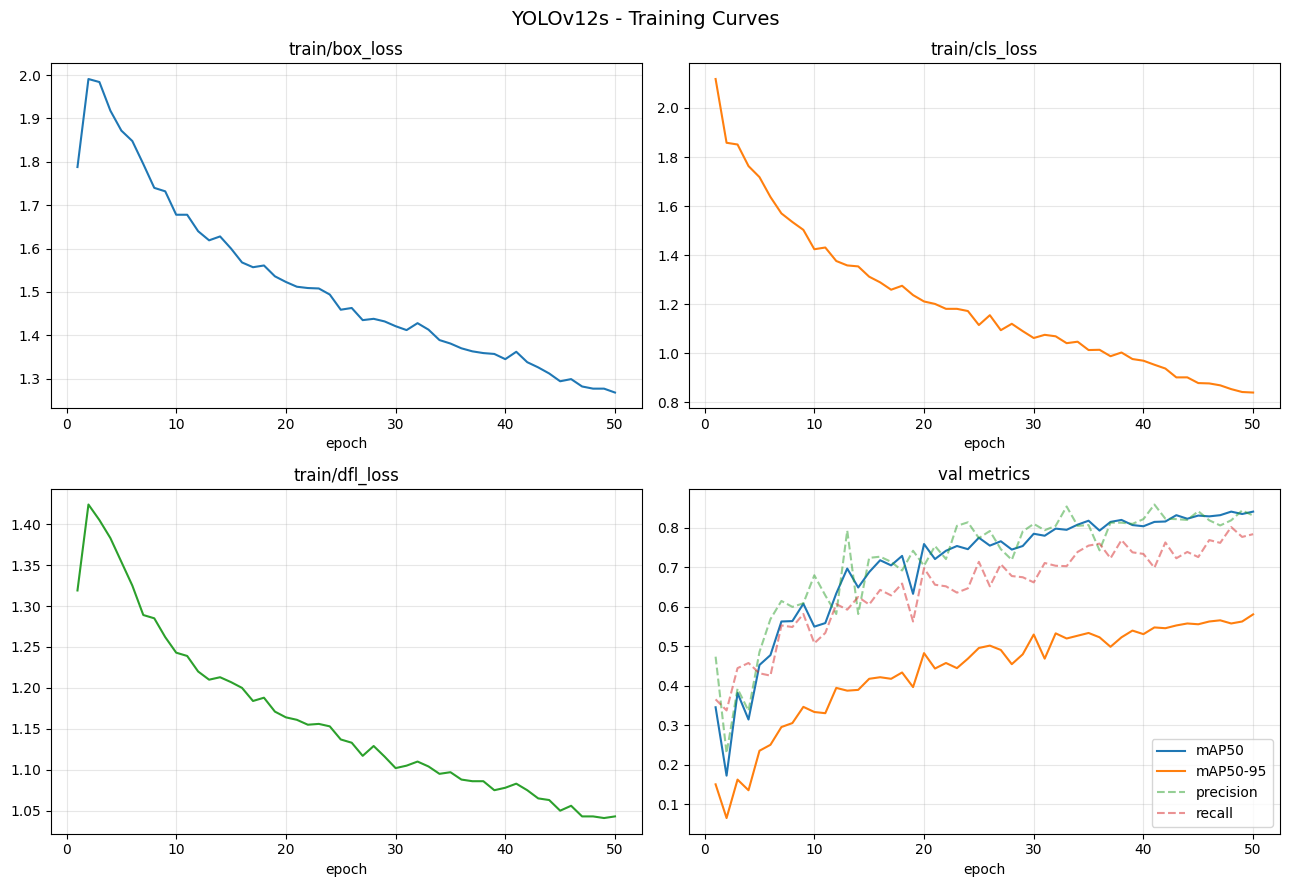

loss_curves.png, results_recovered.csv 저장 완료


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 로그(epoch 1~50)에서 뽑은 값 — results.csv 없어도 이 안에 다 있음
# 컬럼: epoch, box_loss, cls_loss, dfl_loss, P, R, mAP50, mAP50-95
data = [
    (1, 1.788, 2.118, 1.319, 0.474, 0.366, 0.346, 0.151),
    (2, 1.991, 1.858, 1.424, 0.230, 0.338, 0.173, 0.0657),
    (3, 1.984, 1.851, 1.405, 0.393, 0.445, 0.382, 0.163),
    (4, 1.918, 1.763, 1.383, 0.337, 0.458, 0.315, 0.136),
    (5, 1.872, 1.718, 1.354, 0.486, 0.432, 0.453, 0.236),
    (6, 1.848, 1.637, 1.325, 0.569, 0.426, 0.478, 0.251),
    (7, 1.795, 1.570, 1.289, 0.615, 0.553, 0.563, 0.296),
    (8, 1.740, 1.535, 1.285, 0.600, 0.549, 0.564, 0.306),
    (9, 1.732, 1.503, 1.262, 0.609, 0.582, 0.608, 0.347),
    (10, 1.678, 1.424, 1.243, 0.680, 0.508, 0.550, 0.334),
    (11, 1.678, 1.431, 1.239, 0.629, 0.534, 0.559, 0.331),
    (12, 1.640, 1.376, 1.220, 0.582, 0.607, 0.634, 0.395),
    (13, 1.619, 1.358, 1.210, 0.793, 0.593, 0.697, 0.388),
    (14, 1.628, 1.354, 1.213, 0.582, 0.625, 0.649, 0.390),
    (15, 1.600, 1.312, 1.207, 0.724, 0.606, 0.688, 0.418),
    (16, 1.568, 1.289, 1.200, 0.727, 0.643, 0.718, 0.422),
    (17, 1.557, 1.259, 1.184, 0.714, 0.629, 0.705, 0.418),
    (18, 1.561, 1.275, 1.188, 0.692, 0.659, 0.729, 0.434),
    (19, 1.536, 1.237, 1.171, 0.742, 0.563, 0.633, 0.397),
    (20, 1.523, 1.211, 1.164, 0.704, 0.698, 0.759, 0.483),
    (21, 1.512, 1.201, 1.161, 0.754, 0.656, 0.721, 0.444),
    (22, 1.509, 1.181, 1.155, 0.721, 0.652, 0.742, 0.458),
    (23, 1.508, 1.181, 1.156, 0.805, 0.636, 0.754, 0.445),
    (24, 1.494, 1.172, 1.153, 0.814, 0.647, 0.746, 0.469),
    (25, 1.459, 1.115, 1.137, 0.774, 0.714, 0.775, 0.496),
    (26, 1.463, 1.155, 1.133, 0.792, 0.652, 0.755, 0.502),
    (27, 1.435, 1.094, 1.117, 0.746, 0.708, 0.766, 0.491),
    (28, 1.438, 1.120, 1.129, 0.719, 0.678, 0.745, 0.455),
    (29, 1.432, 1.090, 1.116, 0.791, 0.675, 0.754, 0.480),
    (30, 1.421, 1.062, 1.102, 0.810, 0.662, 0.785, 0.530),
    (31, 1.412, 1.075, 1.105, 0.794, 0.711, 0.780, 0.469),
    (32, 1.428, 1.069, 1.110, 0.805, 0.704, 0.798, 0.533),
    (33, 1.413, 1.041, 1.104, 0.854, 0.703, 0.795, 0.520),
    (34, 1.389, 1.047, 1.095, 0.805, 0.739, 0.808, 0.527),
    (35, 1.381, 1.013, 1.097, 0.807, 0.755, 0.818, 0.534),
    (36, 1.370, 1.014, 1.088, 0.743, 0.760, 0.793, 0.523),
    (37, 1.363, 0.9878, 1.086, 0.813, 0.723, 0.815, 0.499),
    (38, 1.359, 1.003, 1.086, 0.813, 0.769, 0.820, 0.523),
    (39, 1.357, 0.9763, 1.075, 0.810, 0.738, 0.807, 0.540),
    (40, 1.345, 0.9695, 1.078, 0.822, 0.734, 0.804, 0.531),
    (41, 1.362, 0.9531, 1.083, 0.859, 0.699, 0.815, 0.548),
    (42, 1.338, 0.9376, 1.075, 0.823, 0.763, 0.816, 0.546),
    (43, 1.326, 0.9015, 1.065, 0.822, 0.723, 0.832, 0.553),
    (44, 1.312, 0.9016, 1.063, 0.820, 0.739, 0.823, 0.558),
    (45, 1.294, 0.8783, 1.050, 0.842, 0.726, 0.831, 0.556),
    (46, 1.299, 0.8769, 1.056, 0.819, 0.769, 0.829, 0.563),
    (47, 1.282, 0.8691, 1.043, 0.806, 0.762, 0.832, 0.566),
    (48, 1.277, 0.8537, 1.043, 0.819, 0.802, 0.841, 0.558),
    (49, 1.277, 0.8419, 1.041, 0.844, 0.777, 0.835, 0.563),
    (50, 1.268, 0.8397, 1.043, 0.831, 0.784, 0.841, 0.581),
]
cols = ["epoch", "box_loss", "cls_loss", "dfl_loss", "P", "R", "mAP50", "mAP50-95"]
df = pd.DataFrame(data, columns=cols)

# ── 그래프 ──
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(df["epoch"], df["box_loss"], color="tab:blue")
axes[0, 0].set_title("train/box_loss")

axes[0, 1].plot(df["epoch"], df["cls_loss"], color="tab:orange")
axes[0, 1].set_title("train/cls_loss")

axes[1, 0].plot(df["epoch"], df["dfl_loss"], color="tab:green")
axes[1, 0].set_title("train/dfl_loss")

axes[1, 1].plot(df["epoch"], df["mAP50"], label="mAP50")
axes[1, 1].plot(df["epoch"], df["mAP50-95"], label="mAP50-95")
axes[1, 1].plot(df["epoch"], df["P"], "--", alpha=.5, label="precision")
axes[1, 1].plot(df["epoch"], df["R"], "--", alpha=.5, label="recall")
axes[1, 1].set_title("val metrics")
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel("epoch")
    ax.grid(alpha=.3)

fig.suptitle("YOLOv12s - Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120)   # 파일로도 저장
plt.show()

# CSV로도 남기고 싶으면 (results.csv 대체품)
df.to_csv("results_recovered.csv", index=False)
print("loss_curves.png, results_recovered.csv 저장 완료")